In [69]:
from prophet import Prophet
from prophet.diagnostics import cross_validation, performance_metrics
from prophet.plot import plot_cross_validation_metric

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error, mean_squared_error

In [70]:
df= pd.read_csv('../data collections/germany.csv')

In [71]:
# Prophet kräver exakt två kolumner:
# ds = datum/tid
# y = värdet som ska förutsägas

df = df.dropna(axis=0).copy()

df['ds'] = pd.to_datetime(df['start'], utc=True).dt.tz_convert(None)
df = df.rename(columns={'load': 'y'})
df = df[['ds', 'y']].sort_values('ds').reset_index(drop=True)

df.head()

,ds,y
0,2015-01-01 00:00:00,41917.0
1,2015-01-01 00:15:00,41518.0
2,2015-01-01 00:30:00,41179.0
3,2015-01-01 00:45:00,40756.0
4,2015-01-01 01:00:00,40618.0


array([[<Axes: title={'center': 'ds'}>, <Axes: title={'center': 'y'}>]],
      dtype=object)

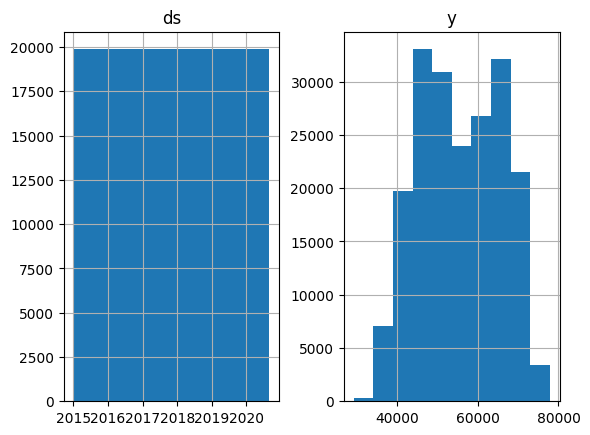

In [72]:
df.hist()

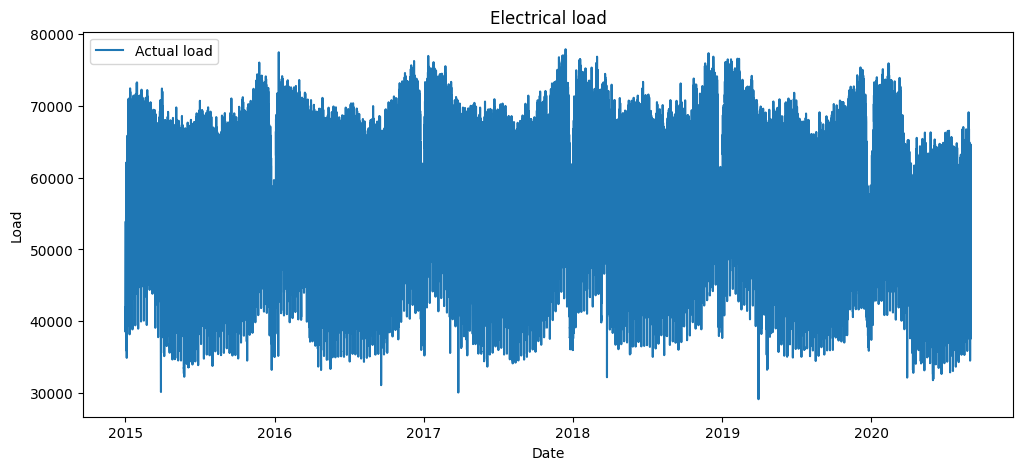

In [73]:
plt.figure(figsize=(12, 5))
plt.plot(df['ds'], df['y'], label='Actual load')
plt.xlabel('Date')
plt.ylabel('Load')
plt.title('Electrical load')
plt.legend()
plt.show()

In [81]:
split_date = '2018-01-01'
train_df = df[df['ds'] < split_date].copy()
test_df = df[df['ds'] >= split_date].copy()

print('Train shape:', train_df.shape)
print('Test shape:', test_df.shape)
print(train_df.head())
print(test_df.head())

Train shape: (105216, 2)
Test shape: (93498, 2)
                   ds        y
0 2015-01-01 00:00:00  41917.0
1 2015-01-01 00:15:00  41518.0
2 2015-01-01 00:30:00  41179.0
3 2015-01-01 00:45:00  40756.0
4 2015-01-01 01:00:00  40618.0
                        ds        y
105216 2018-01-01 00:00:00  41108.0
105217 2018-01-01 00:15:00  40691.0
105218 2018-01-01 00:30:00  40215.0
105219 2018-01-01 00:45:00  40437.0
105220 2018-01-01 01:00:00  40554.0


In [82]:
model = Prophet()
model.fit(train_df)

12:42:14 - cmdstanpy - INFO - Chain [1] start processing
12:42:52 - cmdstanpy - INFO - Chain [1] done processing


In [83]:
# Viktigt:
# periods ska vara antal framtida rader, inte antal kolumner.
# freq='15min' eftersom datan är i 15-minutersintervall.

future = model.make_future_dataframe(
    periods=len(test_df),
    freq='15min',
    include_history=False
)

forecast = model.predict(future)
forecast[['ds', 'yhat', 'yhat_lower', 'yhat_upper']].head()


,ds,yhat,yhat_lower,yhat_upper
0,2018-01-01 00:00:00,38118.439700,33449.874068,42897.529828
1,2018-01-01 00:15:00,37875.471186,33041.685233,42813.976719
2,2018-01-01 00:30:00,37681.964919,32905.137332,42913.379001
3,2018-01-01 00:45:00,37546.781091,32607.834018,42341.747359
4,2018-01-01 01:00:00,37480.004401,33075.626315,42210.873274


In [84]:
# Jämför forecast med test-datan på samma tidsstämplar.

comparison = test_df.merge(
    forecast[['ds', 'yhat', 'yhat_lower', 'yhat_upper']],
    on='ds',
    how='inner'
)

comparison.head()


,ds,y,yhat,yhat_lower,yhat_upper
0,2018-01-01 00:00:00,41108.0,38118.439700,33449.874068,42897.529828
1,2018-01-01 00:15:00,40691.0,37875.471186,33041.685233,42813.976719
2,2018-01-01 00:30:00,40215.0,37681.964919,32905.137332,42913.379001
3,2018-01-01 00:45:00,40437.0,37546.781091,32607.834018,42341.747359
4,2018-01-01 01:00:00,40554.0,37480.004401,33075.626315,42210.873274


In [85]:
mae = mean_absolute_error(comparison['y'], comparison['yhat'])
rmse = np.sqrt(mean_squared_error(comparison['y'], comparison['yhat']))

print('MAE:', mae)
print('RMSE:', rmse)

MAE: 3149.8361832929545
RMSE: 4180.6573977058215


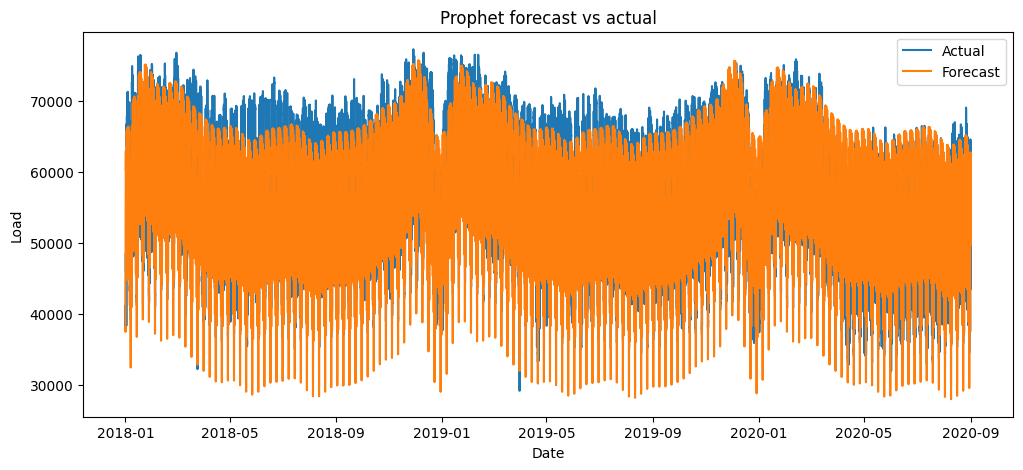

In [86]:
plt.figure(figsize=(12, 5))
plt.plot(comparison['ds'], comparison['y'], label='Actual')
plt.plot(comparison['ds'], comparison['yhat'], label='Forecast')
plt.xlabel('Date')
plt.ylabel('Load')
plt.title('Prophet forecast vs actual')
plt.legend()
plt.show()

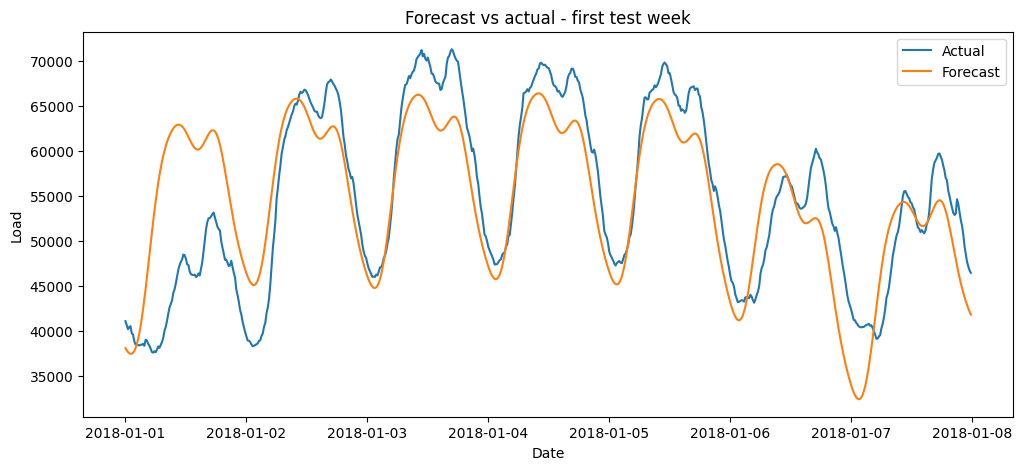

In [87]:
# Zooma in på första veckan så grafen blir läsbar.

one_week = comparison[comparison['ds'] < comparison['ds'].min() + pd.Timedelta(days=7)]

plt.figure(figsize=(12, 5))
plt.plot(one_week['ds'], one_week['y'], label='Actual')
plt.plot(one_week['ds'], one_week['yhat'], label='Forecast')
plt.xlabel('Date')
plt.ylabel('Load')
plt.title('Forecast vs actual - first test week')
plt.legend()
plt.show()